Trying to reproduce phase diagrams from: 

- [Quantum correlations, entanglement spectrum and coherence of two-particle reduced density matrix in the Extended Hubbard Model](https://arxiv.org/pdf/2111.00085)

- [Formation of spin and charge ordering in the extended Hubbard model during a finite-time quantum quench](https://arxiv.org/pdf/2208.05945)


- [Entanglement of indistinguishable particles as a probe for quantum phase transitions in the extended Hubbard model](https://arxiv.org/pdf/1503.08188)

In [399]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os
from scipy.ndimage import gaussian_filter


%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

In [400]:
N_Points = 50
L = 5

In [401]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [402]:
def load_scalar_data(results, model, exec, L, N_Points):
    info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df = pd.read_csv(info_input)

    U_vals = np.sort(df['U'].unique())
    V_vals = np.sort(df['V'].unique())

    U_unique = np.sort(df['U'].unique())
    V_unique = np.sort(df['V'].unique())

    nU = len(U_vals)
    nV = len(V_vals)
    
    Q_2 =           df['Q_2'].values.reshape(nV, nU).T
    Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

    avg_linear_entropy = df['coh_1rdm'].values.reshape(nV, nU).T
    quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

    E_p =           df['E_p'].values.reshape(nV, nU).T
    E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
    E_GS =         df['E_GS'].values.reshape(nV, nU).T

    m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
    m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

    avg_linear_entropy = df['S'].values.reshape(nV, nU).T

    return df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, avg_linear_entropy, Q_2, Q_2_bits, quantum_coherence_2

In [403]:
def load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points):
    magnetization = np.zeros((nV, nU, L))
    charge_density = np.zeros((nV, nU, L))
    doublons = np.zeros((nV, nV, L))

    ent_spec_1rdm = np.zeros((nV, nV, 2*L))
    ent_spec_2rdm = np.zeros((nV, nV, L*(2*L-1)))

    info_input = f"{results}/{model}_{exec}/vector_measures_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df_vecs = pd.read_csv(info_input)

    # Loading the 1-dimensional data frame values. 

    def parse_array(cell):
        return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

    # Apply parsing
    df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
    df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)
    df_vecs["doublons"] = df_vecs["doublons"].apply(parse_array)
    # df_vecs["Omega_1rdm"] = df_vecs["Omega_1rdm"].apply(parse_array)
    # df_vecs["Omega_2rdm"] = df_vecs["Omega_2rdm"].apply(parse_array)

    # thanks gpt
    for _, row in df_vecs.iterrows():
        i = np.where(V_unique == row["V"])[0][0]
        j = np.where(U_unique == row["U"])[0][0]
        magnetization[i, j] = row["magnetization"]
        charge_density[i, j] = row["charge_density"]
        doublons[i, j] = row["doublons"]

        # ent_spec_1rdm[i, j] = row["Omega_1rdm"]
        # ent_spec_2rdm[i, j] = row["Omega_2rdm"]

    return magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm

In [404]:
df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2  = load_scalar_data(results, model, exec, L, N_Points)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

In [405]:
magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points)

In [406]:
tmp = df['E_p'].values.reshape(nV, nU).T

U_target = 5.51
i_U_fixed = np.argmin(np.abs(U_vals - U_target))

print(tmp[i_U_fixed, :])

[0.01461132 0.01447992 0.0143392  0.01420028 0.01406051 0.01392045
 0.01378082 0.01364242 0.01350638 0.01337368 0.01324571 0.01312394
 0.01301008 0.01290611 0.01281426 0.01273712 0.01267763 0.01263913
 0.01262546 0.01264097 0.01269061 0.01278    0.01291547 0.01310418
 0.01335418 0.01367451 0.01407526 0.01456771 0.0151644  0.01587926
 0.01672772 0.01772682 0.01889542 0.02025424 0.02182617 0.02363635
 0.02571252 0.02808525 0.03078836 0.03385946 0.03734063 0.04127945
 0.04573028 0.05075586 0.05642908 0.06283487 0.07007238 0.07825743
 0.08752449 0.09802613]


In [407]:
# gaps_1rdm = np.diff(ent_spec_1rdm)#[0, 0]
# gaps_2rdm = np.diff(ent_spec_2rdm)#[0, 0]

Don't know why, but this order parameters computed in the julia code give the wrong $|m_{\text{SDW}}|$ and $|m_{\text{CDW}}|$...
Saving the magnetization and charge density made possible to compute in python.

### Order parameters for spin-density wave and charge-density wave

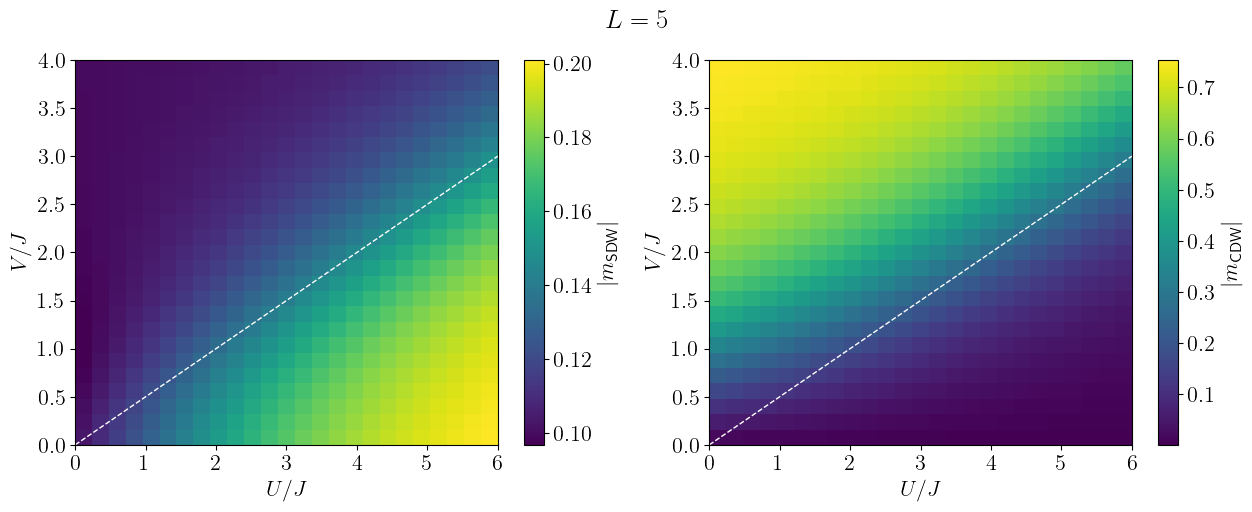

In [408]:
U_min_plot, U_max_plot = 0 , U_max
V_min_plot, V_max_plot = 0 , V_max

def select_region(U_vals, V_vals, data, U_min_plot, U_max_plot, V_min_plot, V_max_plot):
    U_mask = (U_vals >= U_min_plot) & (U_vals <= U_max_plot)
    V_mask = (V_vals >= V_min_plot) & (V_vals <= V_max_plot)
    return U_vals[U_mask], V_vals[V_mask], data[np.ix_(V_mask, U_mask)]

# Slice arrays
U_vals_plot, V_vals_plot, m_sdw_plot = select_region(U_vals, V_vals, m_sdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)
_, _, m_cdw_plot = select_region(U_vals, V_vals, m_cdw, U_min_plot, U_max_plot, V_min_plot, V_max_plot)

# Meshgrid for contours
X, Y = np.meshgrid(U_vals_plot, V_vals_plot)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# m_SDW
im0 = ax[0].imshow(m_sdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
# ax[0].contour(X, Y, np.abs(m_sdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")

# m_CDW
im1 = ax[1].imshow(m_cdw_plot, origin="lower", extent=[U_min_plot, U_max_plot, V_min_plot, V_max_plot], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax[1], label=r"$|m_{\text{CDW}}|$")
# ax[1].contour(X, Y, np.abs(m_cdw_plot), colors='white', linestyle='--', linewidths=0.7)
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

# Line U = 2V
V_range = np.linspace(max(0, V_min_plot), min(U_max_plot / 2, V_max_plot), N_Points)
U_range = 2 * V_range
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save and show
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_U={U_min_plot}-{U_max_plot}_V={V_min_plot}-{V_max_plot}.png", dpi=300, bbox_inches="tight")
plt.show()

#### Energy

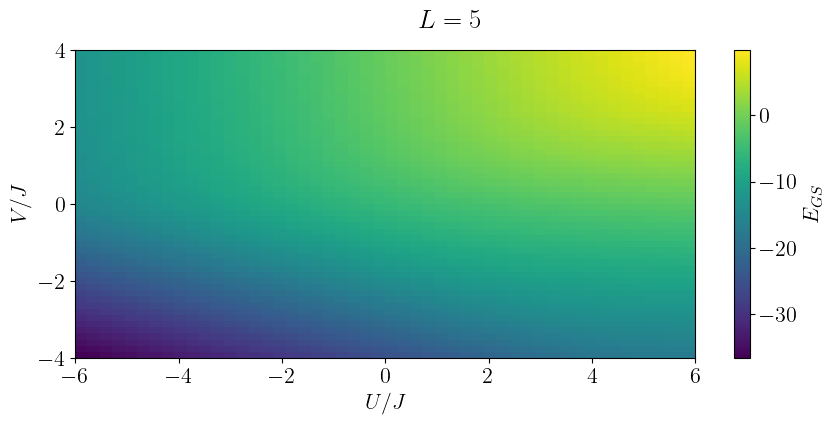

In [409]:
# Create a figure with two subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
    
im0 = ax.imshow(E_GS, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$V / J$")

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax.plot(U_range, V_range, 'w--', linewidth=1)  
plt.suptitle(f"$L = {L}$")
plt.show()
fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')

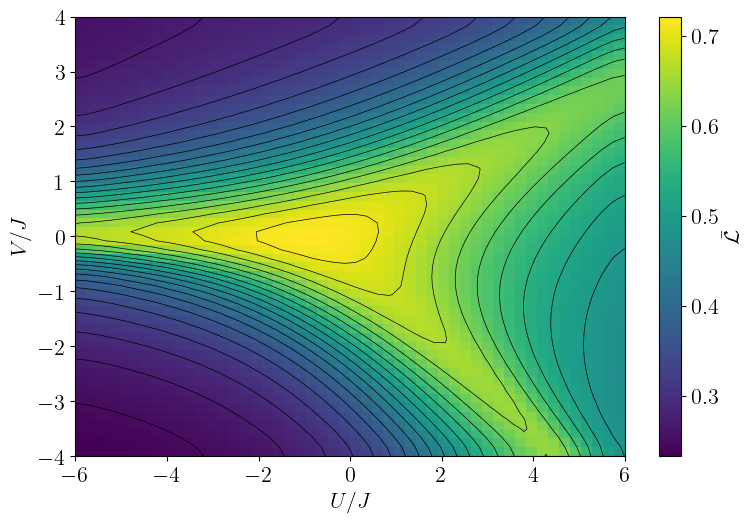

In [410]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 1 , figsize=(8, 6))

sigma_smoothing = 1.5
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.

avg_linear_entropy_smoothed = gaussian_filter(avg_linear_entropy, sigma=sigma_smoothing)

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_max)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im0 = ax1.imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1, orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")
ax1.contour(X, Y, avg_linear_entropy_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)

ax1.set_ylabel(r"$V / J$")
ax1.set_xlabel(r"$U / J$")

# ax1.set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.savefig(f"{figures_path}/{model}_{exec}/single_site_entanglement_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

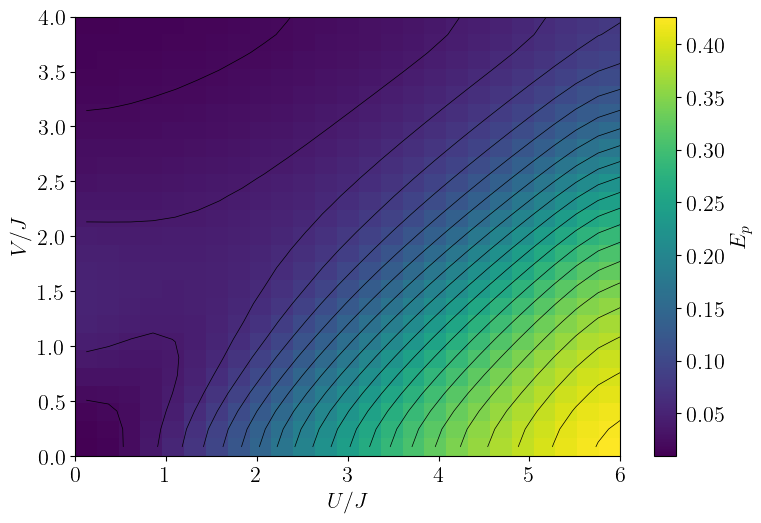

In [411]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 1 , figsize=(8, 6))

sigma_smoothing = 1.5
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = 0.0 # np.min(U_vals)
U_max = np.max(U_vals)
V_min = 0.0 # np.min(V_vals)
V_max = np.max(V_vals)

# Contour 
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
U_vals_new = U_vals[mask_U]

mask_V = (V_vals >= V_min) & (V_vals <= V_max)
V_vals_new = V_vals[mask_V]

# Apply masks to the data array and smooth it
E_p_masked = E_p[mask_V, :]  # Mask rows (V-axis)
E_p_masked = E_p_masked[:, mask_U] # Mask columns (U-axis)
E_p_smoothed = gaussian_filter(E_p_masked, sigma=sigma_smoothing)

X, Y = np.meshgrid(U_vals_new, V_vals_new)

im0 = ax1.imshow(E_p_smoothed, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax=ax1, orientation='vertical', label=r"$E_p$")
ax1.contour(X, Y, E_p_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1.set_ylabel(r"$V / J$")
ax1.set_xlabel(r"$U / J$")

# ax1.set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.savefig(f"{figures_path}/{model}_{exec}/E_p_smoothed_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

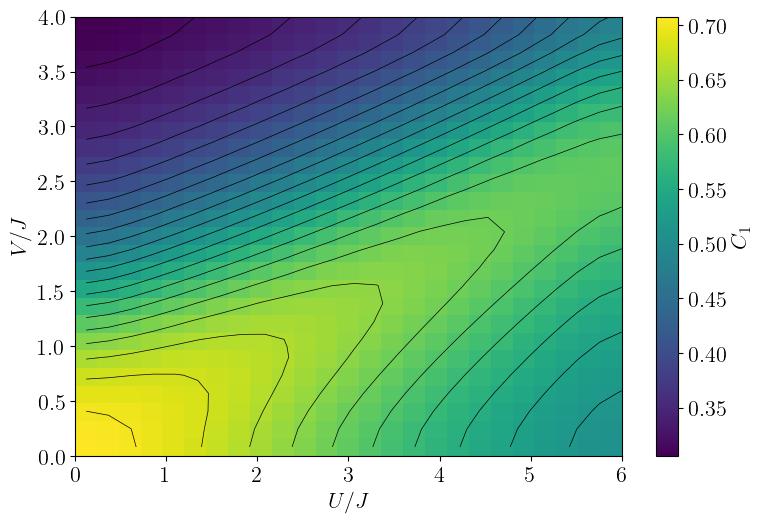

In [412]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 1 , figsize=(8, 6))

sigma_smoothing = 1.5
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.

U_min = 0.0 # np.min(U_vals)
U_max = np.max(U_vals)
V_min = 0.0 # np.min(V_vals)
V_max = np.max(V_vals)

# Contour 
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
U_vals_new = U_vals[mask_U]

mask_V = (V_vals >= V_min) & (V_vals <= V_max)
V_vals_new = V_vals[mask_V]

# Apply masks to the data array and smooth it
quantum_coherence_1_masked = quantum_coherence_1[mask_V, :]  # Mask rows (V-axis)
quantum_coherence_1_masked = quantum_coherence_1_masked[:, mask_U] # Mask columns (U-axis)
quantum_coherence_1_masked = gaussian_filter(quantum_coherence_1_masked, sigma=sigma_smoothing)

X, Y = np.meshgrid(U_vals_new, V_vals_new)

im0 = ax1.imshow(quantum_coherence_1_masked, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax=ax1, orientation='vertical', label=r"$C_1$")
ax1.contour(X, Y, quantum_coherence_1_masked, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1.set_ylabel(r"$V / J$")
ax1.set_xlabel(r"$U / J$")

# ax1.set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.savefig(f"{figures_path}/{model}_{exec}/quantum_coherence_smoothed_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

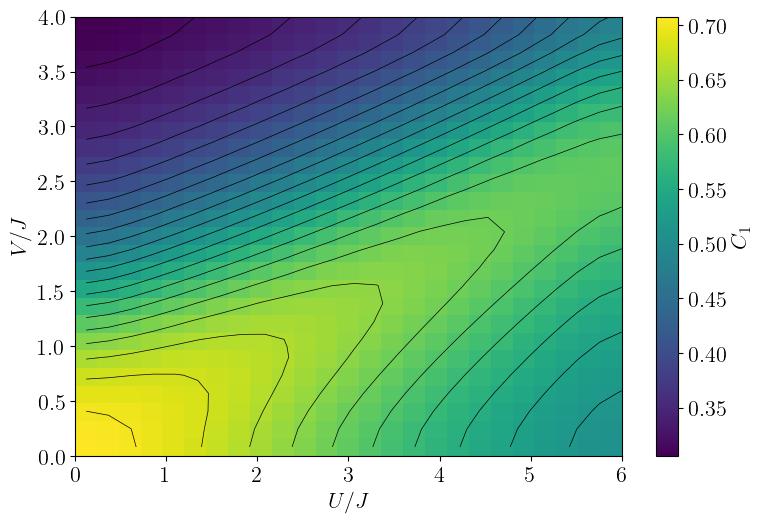

In [413]:
# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 1 , figsize=(8, 6))

sigma_smoothing = 1.5
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.

U_min = 0.0 # np.min(U_vals)
U_max = np.max(U_vals)
V_min = 0.0 # np.min(V_vals)
V_max = np.max(V_vals)

# Contour 
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
U_vals_new = U_vals[mask_U]

mask_V = (V_vals >= V_min) & (V_vals <= V_max)
V_vals_new = V_vals[mask_V]

# Apply masks to the data array and smooth it
avg_linear_entropy_masked = avg_linear_entropy[mask_V, :]  # Mask rows (V-axis)
avg_linear_entropy_masked = avg_linear_entropy_masked[:, mask_U] # Mask columns (U-axis)
avg_linear_entropy_masked = gaussian_filter(avg_linear_entropy_masked, sigma=sigma_smoothing)

X, Y = np.meshgrid(U_vals_new, V_vals_new)

im0 = ax1.imshow(avg_linear_entropy_masked, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax=ax1, orientation='vertical', label=r"$C_1$")
ax1.contour(X, Y, avg_linear_entropy_masked, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1.set_ylabel(r"$V / J$")
ax1.set_xlabel(r"$U / J$")

# ax1.set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig.savefig(f"{figures_path}/{model}_{exec}/avg_linear_entropy_smoothed_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

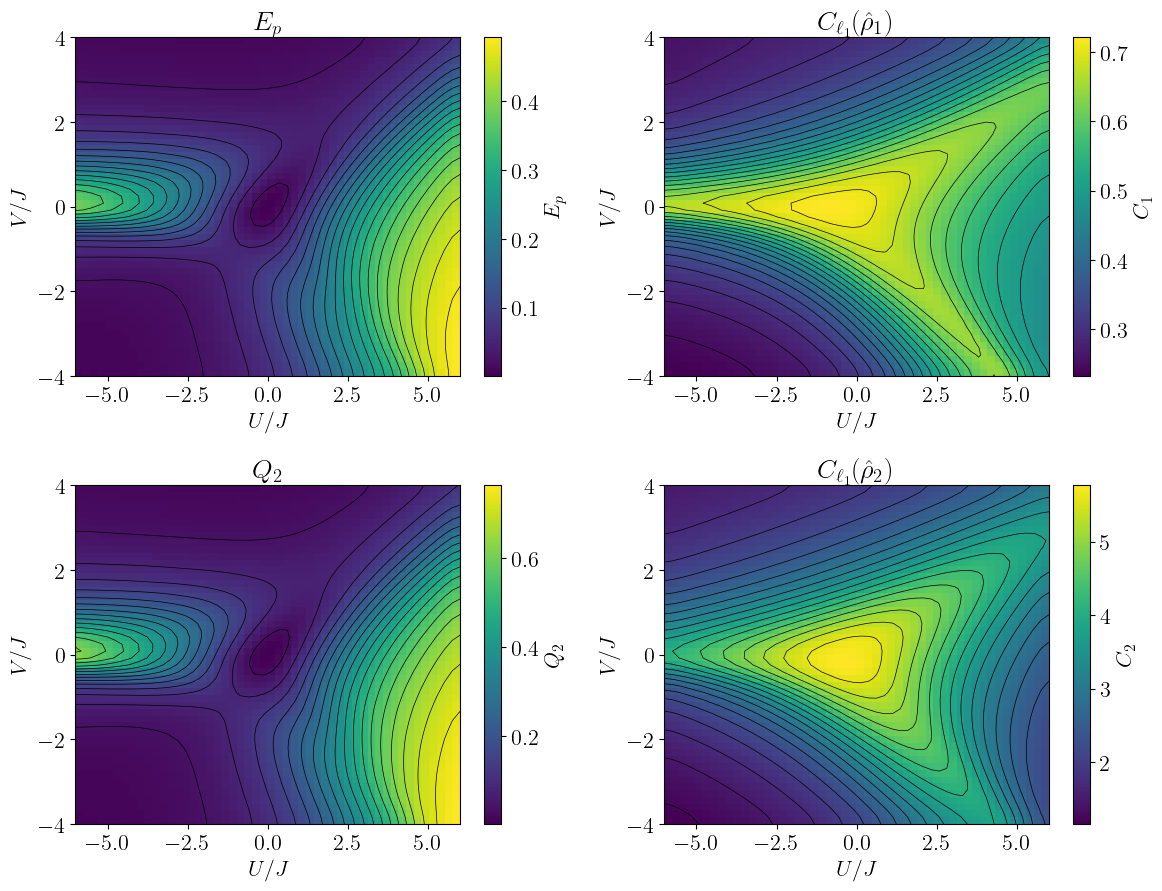

In [414]:
# --- Smoothing Parameters ---
# Sigma controls the degree of smoothing. Higher sigma means more smoothing.
# For a 50x50 grid, a sigma between 1 and 3 is often a good starting point.
# Experiment with this value to find what looks best for your data.

sigma_smoothing = 1.5

# --- Contour Levels Parameter ---
# Number of contour lines you want to see.
# A higher number will result in more contour lines.
num_contour_levels = 20 # You can increase this to 30, 40, 50, etc.
# Alternatively, you can specify exact levels:
# custom_levels = np.linspace(E_p.min(), E_p.max(), num_contour_levels)

# Create a figure with two subplots
fig, ax1 = plt.subplots(2, 2, figsize=(12, 10))
# plt.suptitle(f"$L = {L}$")

# Calculate min/max for extent from U_vals and V_vals
U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_vals)

# Create meshgrid for contour plotting
X, Y = np.meshgrid(U_vals, V_vals)

# --- Plot 1: E_p ---
# Apply Gaussian filter for smoothing E_p data
E_p_smoothed = gaussian_filter(E_p, sigma=sigma_smoothing)
im1 = ax1[0, 0].imshow(E_p, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax1[0, 0], orientation='vertical', label=r"$E_p$")
# Plot contours using the smoothed E_p data and specified number of levels
ax1[0, 0].contour(X, Y, E_p_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[0, 0].set_xlabel(r"$U / J$")
ax1[0, 0].set_ylabel(r"$V / J$")
ax1[0, 0].set_title(r"$E_p$")

# --- Plot 2: avg_linear_entropy ---
# Apply Gaussian filter for smoothing quantum_coherence_1 data
quantum_coherence_1_smoothed = gaussian_filter(quantum_coherence_1, sigma=sigma_smoothing)

im2 = ax1[0, 1].imshow(quantum_coherence_1, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im2, ax=ax1[0, 1], orientation='vertical', label=r"$C_1$")
# Plot contours using the smoothed quantum_coherence_1 data and specified number of levels
ax1[0, 1].contour(X, Y, quantum_coherence_1_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[0, 1].set_xlabel(r"$U / J$")
ax1[0, 1].set_ylabel(r"$V / J$")
ax1[0, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_1)$") #  = \sum_{i\neq j}|(\hat{\rho}_1)_{i, j}|$")

# --- Plot 3: Q_2 ---
# Apply Gaussian filter for smoothing Q_2 data
Q_2_smoothed = gaussian_filter(Q_2, sigma=sigma_smoothing)

im3 = ax1[1, 0].imshow(Q_2, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im3, ax=ax1[1, 0], orientation='vertical', label=r"$Q_2$")
# Plot contours using the smoothed Q_2 data and specified number of levels
ax1[1, 0].contour(X, Y, Q_2_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[1, 0].set_xlabel(r"$U / J$")
ax1[1, 0].set_ylabel(r"$V / J$")
ax1[1, 0].set_title(r"$Q_2$") 
# --- Plot 4: quantum_coherence_2 ---
# Apply Gaussian filter for smoothing quantum_coherence_2 data
quantum_coherence_2_smoothed = gaussian_filter(quantum_coherence_2, sigma=sigma_smoothing)

im4 = ax1[1, 1].imshow(quantum_coherence_2, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)
fig.colorbar(im4, ax=ax1[1, 1], orientation='vertical', label=r"$C_2$")
# Plot contours using the smoothed quantum_coherence_2 data and specified number of levels
ax1[1, 1].contour(X, Y, quantum_coherence_2_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)
ax1[1, 1].set_xlabel(r"$U / J$")
ax1[1, 1].set_ylabel(r"$V / J$")
ax1[1, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_2)$")

# Adjust layout and save
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

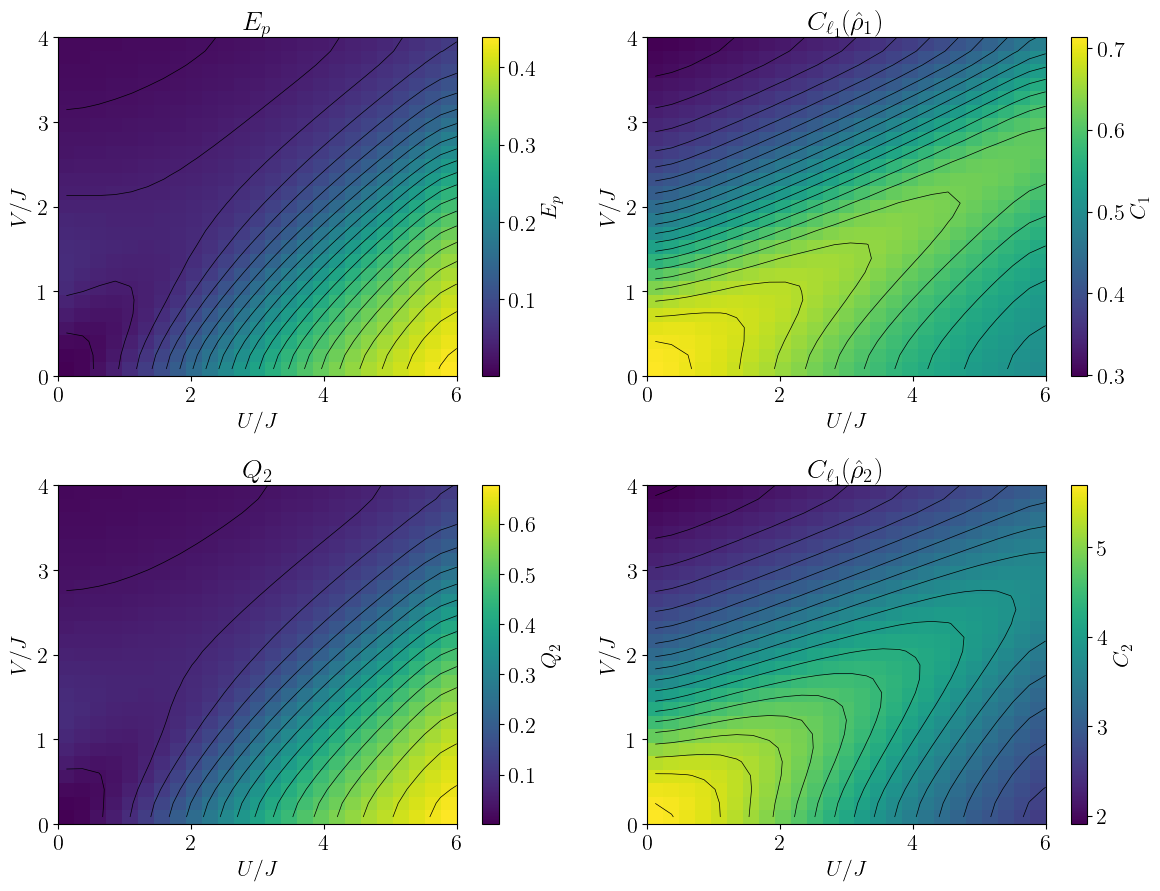

In [415]:
# --- Parameters ---
sigma_smoothing = 1.5
num_contour_levels = 20

# --- Interval selection (adjust these as needed) ---
U_min = 0.0   # for example
U_max = np.max(U_vals)
V_min = 0.0
V_max = np.max(V_vals)

# --- Apply masks to U and V ---
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
U_vals_new = U_vals[mask_U]

mask_V = (V_vals >= V_min) & (V_vals <= V_max)
V_vals_new = V_vals[mask_V]

# --- Create meshgrid for masked range ---
X, Y = np.meshgrid(U_vals_new, V_vals_new)

# --- Apply masks to all data arrays ---
E_p_masked = E_p[mask_V, :][:, mask_U]
quantum_coherence_1_masked = quantum_coherence_1[mask_V, :][:, mask_U]
Q_2_masked = Q_2[mask_V, :][:, mask_U]
quantum_coherence_2_masked = quantum_coherence_2[mask_V, :][:, mask_U]

# --- Apply Gaussian smoothing ---
E_p_smoothed = gaussian_filter(E_p_masked, sigma=sigma_smoothing)
quantum_coherence_1_smoothed = gaussian_filter(quantum_coherence_1_masked, sigma=sigma_smoothing)
Q_2_smoothed = gaussian_filter(Q_2_masked, sigma=sigma_smoothing)
quantum_coherence_2_smoothed = gaussian_filter(quantum_coherence_2_masked, sigma=sigma_smoothing)

# --- Create figure with 4 subplots ---
fig, ax1 = plt.subplots(2, 2, figsize=(12, 10))

# --- Plot 1: E_p ---
im1 = ax1[0, 0].imshow(E_p_masked, origin="lower",
                       extent=[U_min, U_max, V_min, V_max],
                       aspect="auto", cmap=theme)
fig.colorbar(im1, ax=ax1[0, 0], orientation='vertical', label=r"$E_p$")
ax1[0, 0].contour(X, Y, E_p_smoothed, levels=num_contour_levels,
                  colors='black', linewidths=0.5)
ax1[0, 0].set_xlabel(r"$U / J$")
ax1[0, 0].set_ylabel(r"$V / J$")
ax1[0, 0].set_title(r"$E_p$")

# --- Plot 2: quantum_coherence_1 ---
im2 = ax1[0, 1].imshow(quantum_coherence_1_masked, origin="lower",
                       extent=[U_min, U_max, V_min, V_max],
                       aspect="auto", cmap=theme)
fig.colorbar(im2, ax=ax1[0, 1], orientation='vertical', label=r"$C_1$")
ax1[0, 1].contour(X, Y, quantum_coherence_1_smoothed, levels=num_contour_levels,
                  colors='black', linewidths=0.5)
ax1[0, 1].set_xlabel(r"$U / J$")
ax1[0, 1].set_ylabel(r"$V / J$")
ax1[0, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_1)$")

# --- Plot 3: Q_2 ---
im3 = ax1[1, 0].imshow(Q_2_masked, origin="lower",
                       extent=[U_min, U_max, V_min, V_max],
                       aspect="auto", cmap=theme)
fig.colorbar(im3, ax=ax1[1, 0], orientation='vertical', label=r"$Q_2$")
ax1[1, 0].contour(X, Y, Q_2_smoothed, levels=num_contour_levels,
                  colors='black', linewidths=0.5)
ax1[1, 0].set_xlabel(r"$U / J$")
ax1[1, 0].set_ylabel(r"$V / J$")
ax1[1, 0].set_title(r"$Q_2$")

# --- Plot 4: quantum_coherence_2 ---
im4 = ax1[1, 1].imshow(quantum_coherence_2_masked, origin="lower",
                       extent=[U_min, U_max, V_min, V_max],
                       aspect="auto", cmap=theme)
fig.colorbar(im4, ax=ax1[1, 1], orientation='vertical', label=r"$C_2$")
ax1[1, 1].contour(X, Y, quantum_coherence_2_smoothed, levels=num_contour_levels,
                  colors='black', linewidths=0.5)
ax1[1, 1].set_xlabel(r"$U / J$")
ax1[1, 1].set_ylabel(r"$V / J$")
ax1[1, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_2)$")

# --- Final adjustments ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_interval_L={L}_NPoints={N_Points}.png",
            dpi=100, bbox_inches='tight')
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

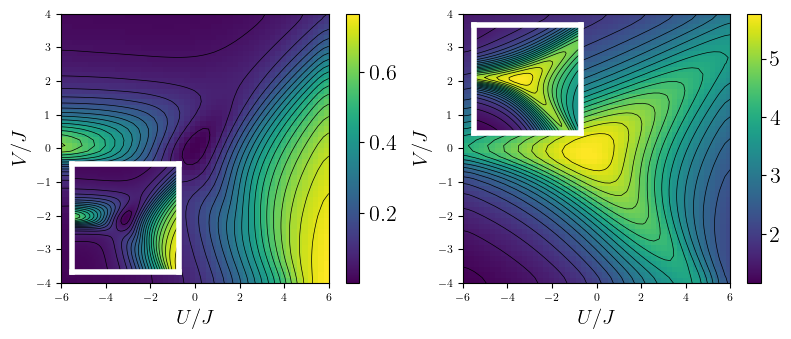

In [416]:
# --- parameters ---
sigma_smoothing    = 1.5
num_contour_levels = 20

# precompute extents & mesh
U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()
X, Y = np.meshgrid(U_vals, V_vals)

# helper to draw an imshow+contour
def draw_map(ax, data):
    sm = gaussian_filter(data, sigma=sigma_smoothing)
    im = ax.imshow(data, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme)
    ax.contour(X, Y, sm, levels=num_contour_levels, colors='k', linewidths=0.5)
    ax.set_xlabel(r"$U/J$", fontsize=15)
    ax.set_ylabel(r"$V/J$", fontsize=15)
    ax.tick_params(labelsize=8)
    return im

# --- figure setup ---
fig, (axQ2, axC2) = plt.subplots(1, 2, figsize=(9.5, 3.5))

# main 1: Q2
imQ2 = draw_map(axQ2, Q_2)
fig.colorbar(imQ2, ax=axQ2, orientation='vertical') # , label=r"$Q_2$")

# inset for E_p
axins1 = inset_axes(axQ2, width="40%", height="40%", loc="lower left")

# give the inset a white background and white border
axins1.set_facecolor("white")
for spine in axins1.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)

draw_map(axins1, E_p)  # no title on inset
axins1.set_xticks([])
axins1.set_yticks([])

axins1.set_xlabel("")
axins1.set_ylabel("")

# main 2: C_l1(rho2)
imC2 = draw_map(axC2, quantum_coherence_2)
fig.colorbar(imC2, ax=axC2, orientation='vertical') # , label=r"$Q_2$")

# inset for C_l1(rho1)
axins2 = inset_axes(axC2, width="40%", height="40%", loc="upper left")

# same white frame on second inset
axins2.set_facecolor("white")
for spine in axins2.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)

draw_map(axins2, quantum_coherence_1)
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_xlabel("")
axins2.set_ylabel("")

im0 = ax1.imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap=theme)# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1, orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")
ax1.contour(X, Y, avg_linear_entropy_smoothed, levels=num_contour_levels, colors='black', linewidths=0.5)



# save & show
plt.savefig(f"{figures_path}/{model}_{exec}/big_Q2_C2_with_insets_L={L}.png", dpi=300, bbox_inches="tight")
plt.show()

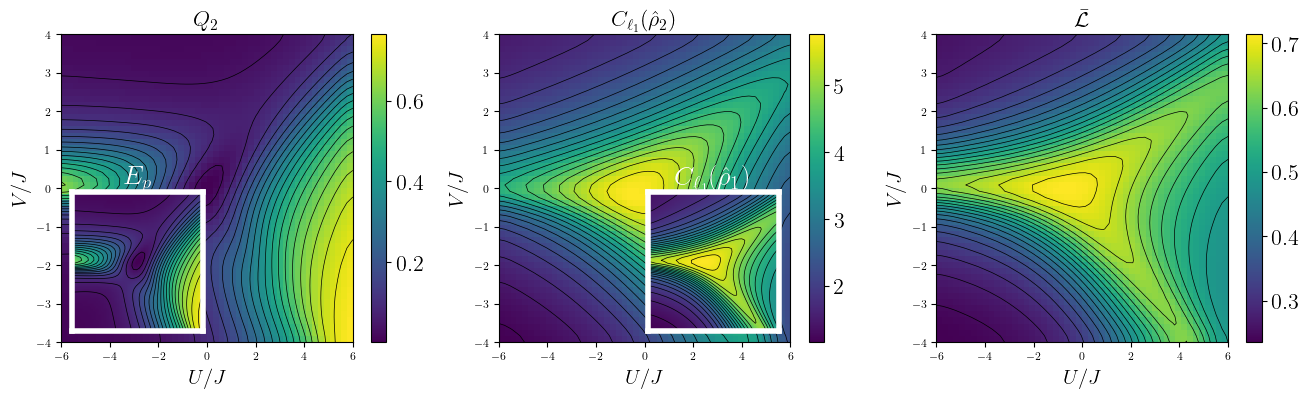

In [417]:
# --- parameters ---
sigma_smoothing    = 1.5
num_contour_levels = 20


# --- Interval selection (adjust these as needed) ---
U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_vals)

# --- apply masks ---
mask_U = (U_vals >= U_min) & (U_vals <= U_max)
mask_V = (V_vals >= V_min) & (V_vals <= V_max)

U_vals_new = U_vals[mask_U]
V_vals_new = V_vals[mask_V]

# meshgrid for masked region
X, Y = np.meshgrid(U_vals_new, V_vals_new)

# masked data arrays
Q_2_masked = Q_2[mask_V, :][:, mask_U]
C2_masked  = quantum_coherence_2[mask_V, :][:, mask_U]
E_p_masked = E_p[mask_V, :][:, mask_U]
C1_masked  = quantum_coherence_1[mask_V, :][:, mask_U]
avg_linear_entropy_masked = avg_linear_entropy[mask_V, :][:, mask_U]
avg_linear_entropy_masked = gaussian_filter(avg_linear_entropy_masked, sigma=sigma_smoothing)

# --- helper to draw an imshow+contour ---
def draw_map(ax, data, U_min, U_max, V_min, V_max, add_labels=True):
    sm = gaussian_filter(data, sigma=sigma_smoothing)
    im = ax.imshow(data, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme)
    ax.contour(X, Y, sm, levels=num_contour_levels, colors='k', linewidths=0.5)
    if add_labels:
        ax.set_xlabel(r"$U/J$", fontsize=15)
        ax.set_ylabel(r"$V/J$", fontsize=15)
    ax.tick_params(labelsize=8)
    return im

# --- figure setup (1 row, 3 columns) ---
fig, (axQ2, axC2, axLE) = plt.subplots(1, 3, figsize=(16, 4))

# === Plot 1: Q2 (inset = E_p) ===
imQ2 = draw_map(axQ2, Q_2_masked, U_min, U_max, V_min, V_max)
fig.colorbar(imQ2, ax=axQ2, orientation='vertical')
axQ2.set_title(r"$Q_2$", fontsize=16)


# inset for E_p
axins1 = inset_axes(axQ2, width="45%", height="45%", loc="lower left")
axins1.set_facecolor("white")
for spine in axins1.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)
draw_map(axins1, E_p_masked, U_min, U_max, V_min, V_max, add_labels=False)
axins1.set_xticks([]); axins1.set_yticks([])

# === Plot 2: C_l1(rho2) (inset = C1) ===
imC2 = draw_map(axC2, C2_masked, U_min, U_max, V_min, V_max)
fig.colorbar(imC2, ax=axC2, orientation='vertical')
axC2.set_title(r"$C_{\ell_1}(\hat{\rho}_2)$", fontsize=16)

# inset for C_l1(rho1)
axins2 = inset_axes(axC2, width="45%", height="45%", loc="lower right")
axins2.set_facecolor("white")

axins1.set_title(r"$E_p$", color="white")

axins1.set_xlabel("")
axins1.set_ylabel("")

for spine in axins2.spines.values():
    spine.set_edgecolor("white")
    spine.set_linewidth(4)
draw_map(axins2, C1_masked, U_min, U_max, V_min, V_max, add_labels=False)
axins2.set_xticks([]); axins2.set_yticks([])
axins2.set_title(r"$C_{\ell_1}(\hat{\rho}_1)$", color="white")

# === Plot 3: avg_linear_entropy (NO inset) ===
imLE = axLE.imshow(avg_linear_entropy_masked, origin="lower",
                   extent=[U_min, U_max, V_min, V_max],
                   aspect="auto", cmap=theme)
fig.colorbar(imLE, ax=axLE, orientation='vertical')
axLE.contour(X, Y, avg_linear_entropy_masked, levels=num_contour_levels, colors='black', linewidths=0.5)
axLE.set_xlabel(r"$U/J$", fontsize=15)
axLE.set_ylabel(r"$V/J$", fontsize=15)
axLE.tick_params(labelsize=8)
axLE.set_title(r"$\bar{\mathcal{L}}$", fontsize=16)

# --- save & show ---
plt.savefig(f"{figures_path}/{model}_{exec}/big_Q2_C2_LE_with_insets_interval_L={L}.png", dpi=300, bbox_inches="tight")
plt.show()

#### Analysis of entanglement in accross different phases

In [ ]:
V_targets_negatives = np.sort([-1.53, -1.32, -1.12, -0.92, -0.72])
V_targets_positives = np.sort([0.1, 0.9, 1.6, 2.32, 1.12, 1.7, 2.1, 3.0])
U_targets_negatives = np.sort([-5.73, -4.75, -2.85, -1.76 ,-0.95, 0.0])
U_targets_positives = np.sort([2.3, 2.6, 0.1, 0.5, 1.5, 3.1, 4.3, 6.0])

# transposing the data was only needed to make the full diagram

Q_2 =           df['Q_2'].values.reshape(nV, nU)# .T

quantum_coherence_1 = df['coh_1rdm'].values.reshape(nV, nU)# .T
quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU)# .T

E_p =           df['E_p'].values.reshape(nV, nU)# .T

#### Fixed $V$ values

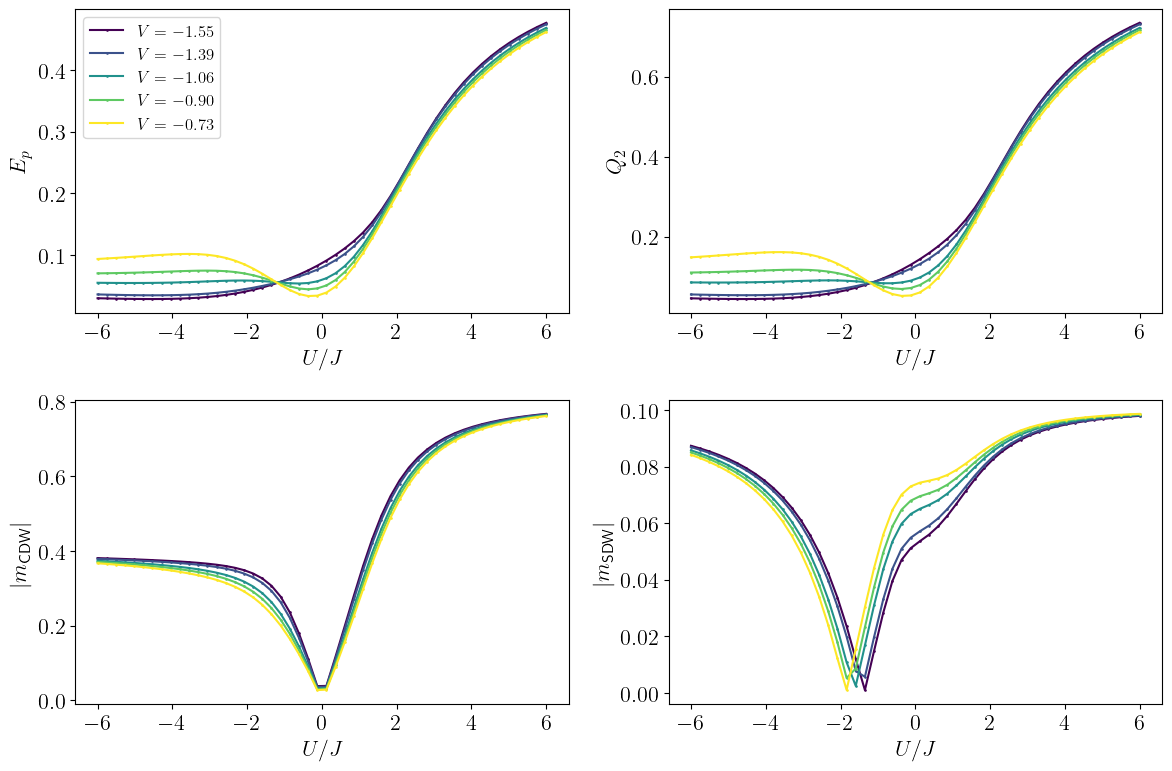

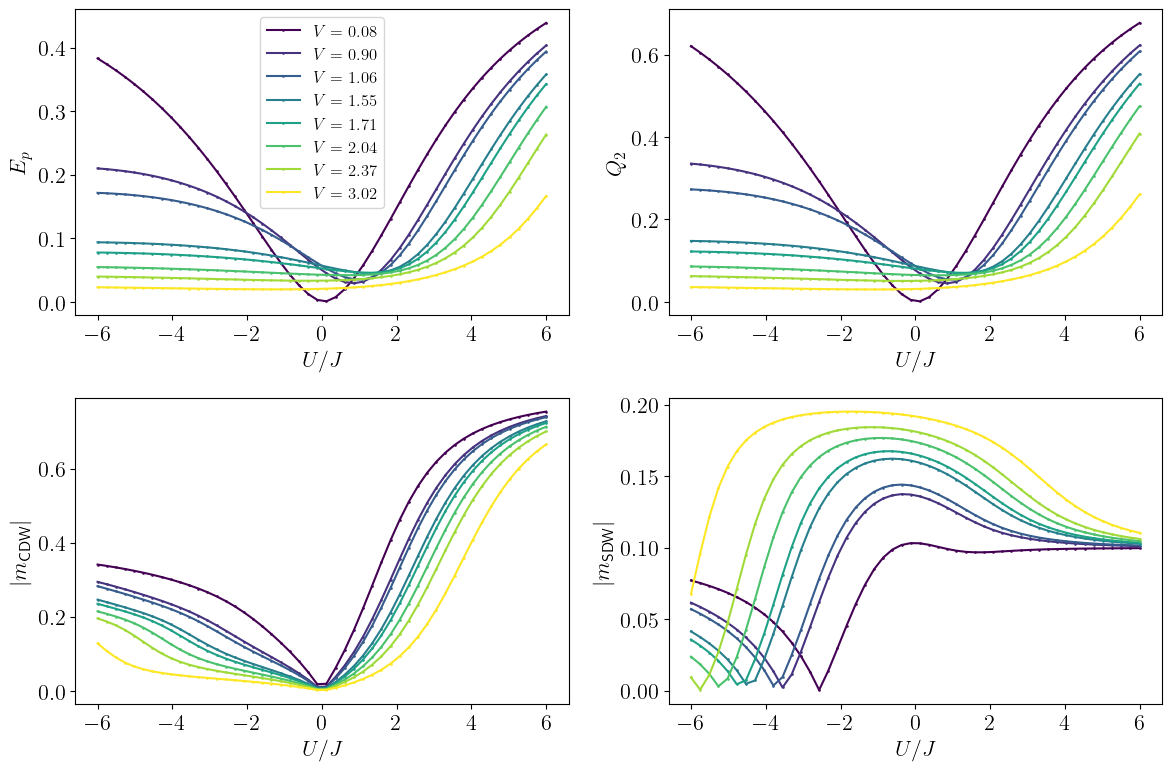

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()

# Positive V plots
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_V_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

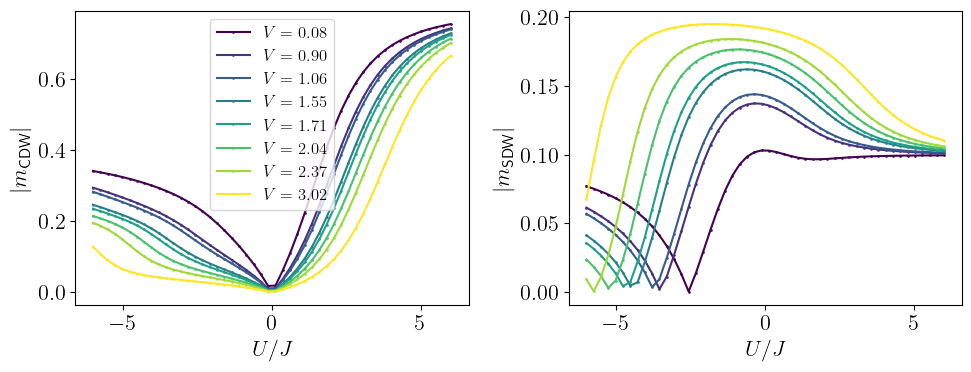

In [ ]:
# Positive V plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals, m_cdw[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=f"$V={V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals, m_sdw[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].set_xlabel(r"$U / J$")
ax[1].set_xlabel(r"$U / J$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

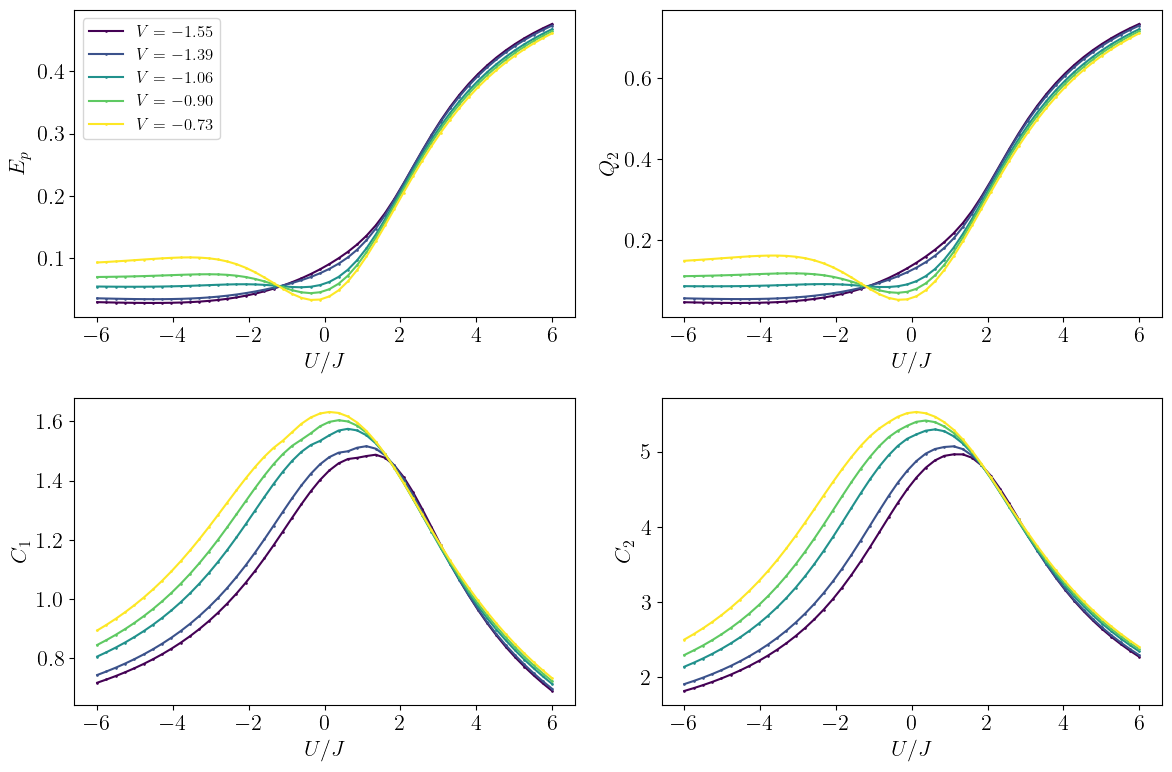

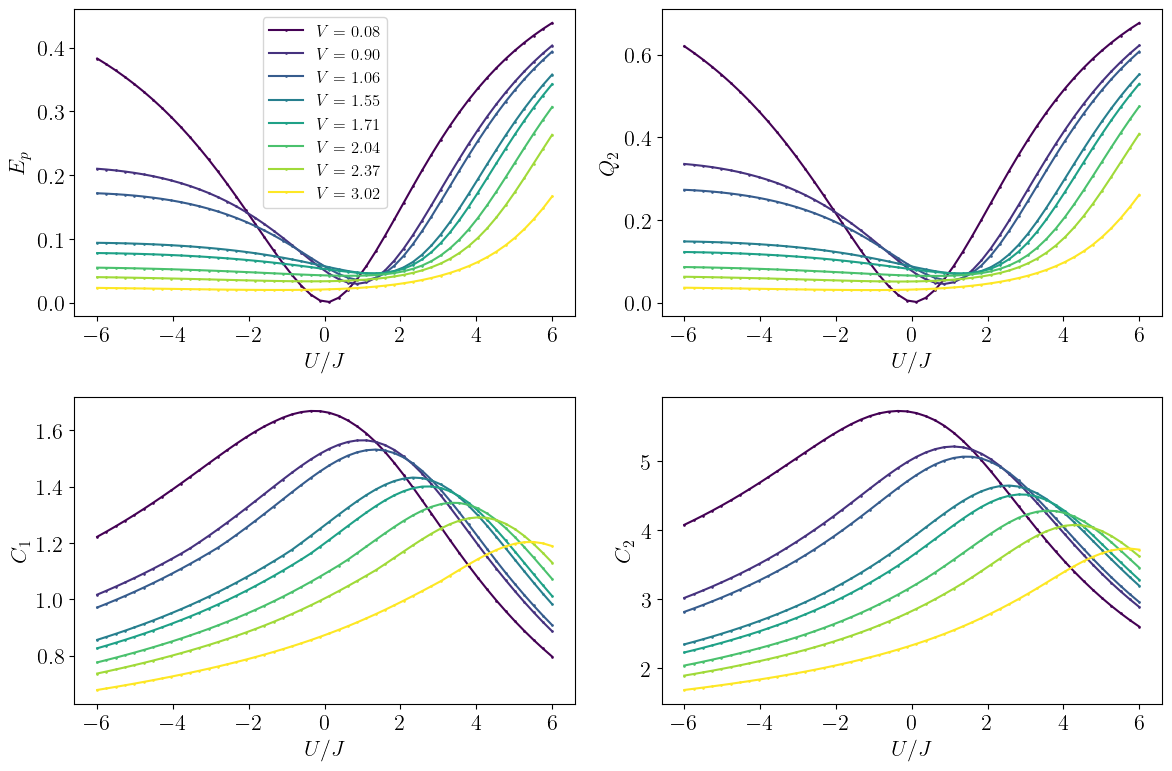

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

colors_pos = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, V_target in zip(colors_pos, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 0].plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")
    ax[0, 1].plot(U_vals, Q_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(U_vals, quantum_coherence_2[:, i_V_fixed], 'o-', markersize=0.9, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].set_xlabel(r"$U / J$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 0].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_V_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

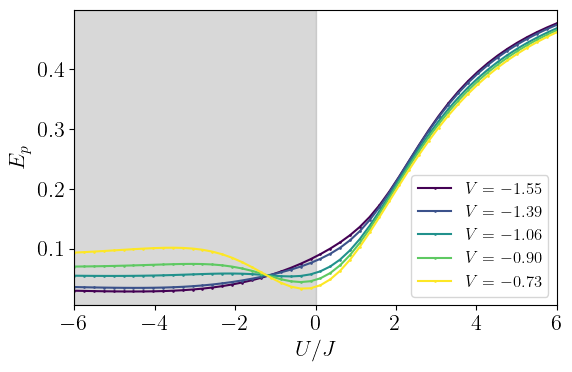

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets_negatives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Add the grey shaded region to both subplots with zorder to place it in the background
ax.axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)

# Manually set the x-axis limits after plotting all data
ax.set_xlim(U_vals.min(), U_vals.max())

for color, V_target in zip(colors_neg, V_targets_negatives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax.plot(U_vals, E_p[:, i_V_fixed], 'o-', markersize=0.9, color=color, label=fr"$V={V_vals[i_V_fixed]:.2f}$")

ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

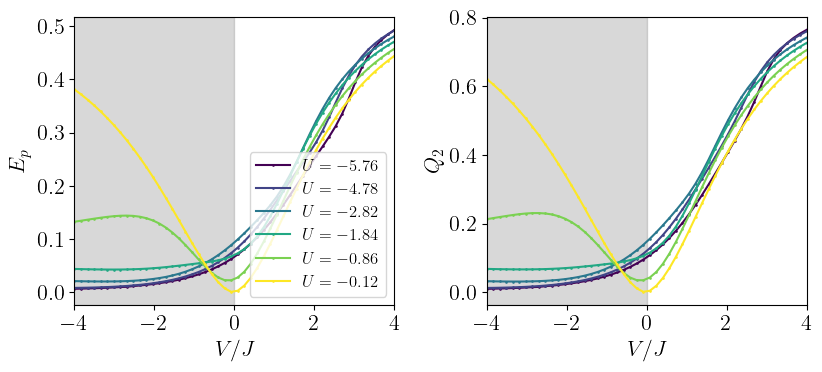

In [ ]:
# Assuming all necessary variables are defined
# cm, U_targets_negatives, U_vals, V_vals, E_p, Q_2, figures_path, model, exec, and L
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 2, figsize=(8.5, 4))

# Add the grey shaded region to both subplots with zorder to place it in the background
ax[0].axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)
ax[1].axvspan(-6.0, 0.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, E_p[:, i_U_fixed], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, Q_2[:, i_U_fixed], 'o-', markersize=0.9, color=color)

# Manually set the x-axis limits after plotting all data
ax[0].set_xlim(V_vals.min(), V_vals.max())
ax[1].set_xlim(V_vals.min(), V_vals.max())

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")
ax[0].set_ylabel(r"$E_p$")
ax[1].set_ylabel(r"$Q_2$")

ax[0].legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

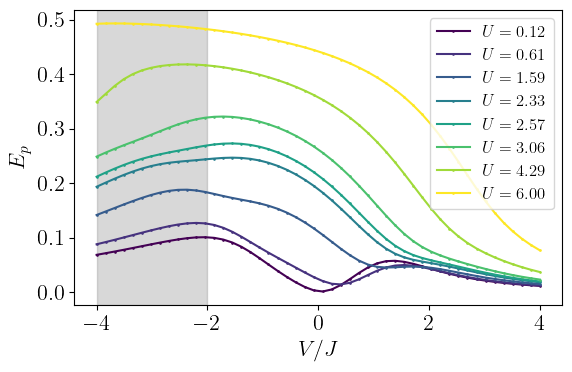

In [ ]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")
# Add the grey shaded region to both subplots with zorder to place it in the background
ax.axvspan(-4.0, -2.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

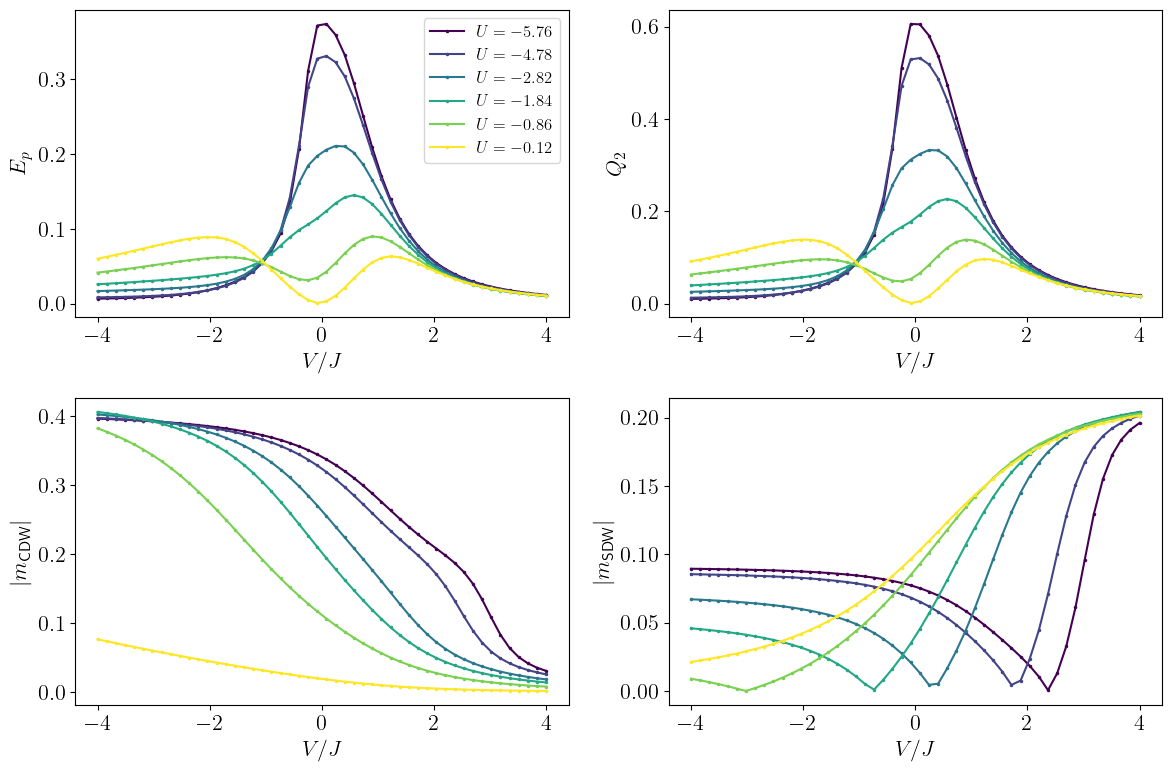

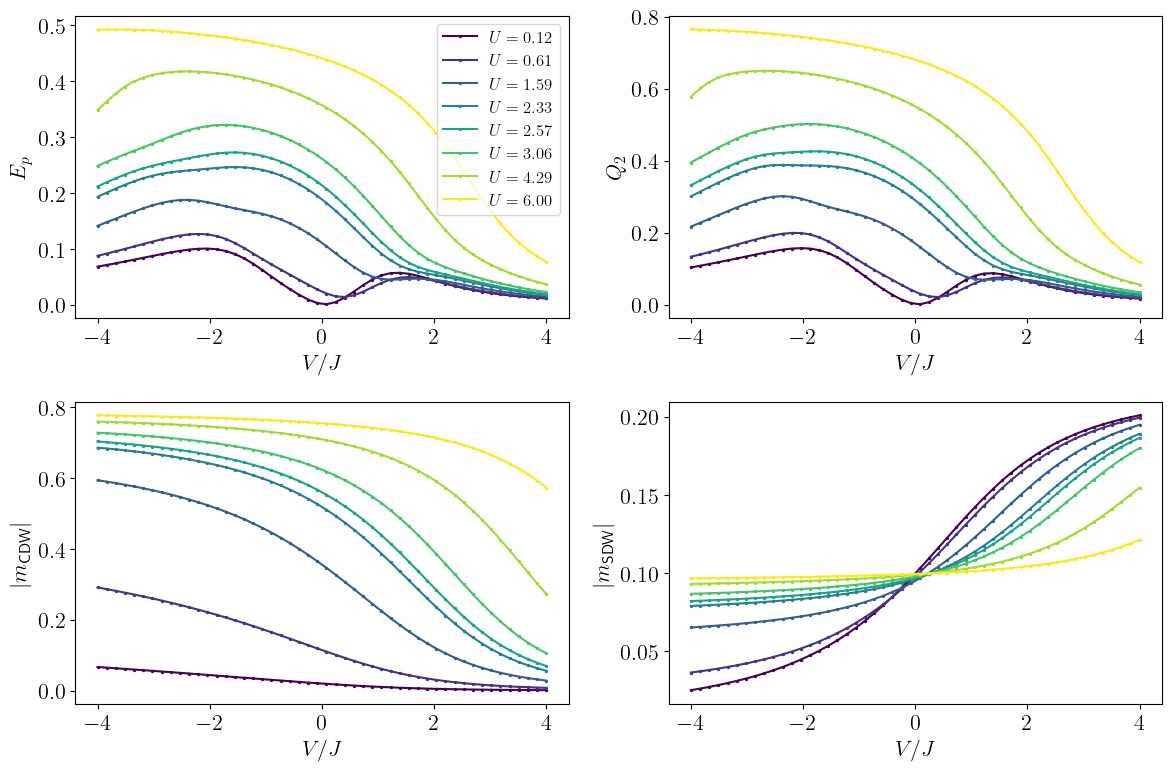

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[i_U_fixed, :], 'o-',   markersize=1.5, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[i_U_fixed, :], 'o-',   markersize=1.5, color=color)
    ax[1, 0].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=1.5, color=color)
    ax[1, 1].plot(V_vals, m_sdw[i_U_fixed, :], 'o-', markersize=1.5, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()


colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,   E_p[i_U_fixed, :], 'o-', markersize=1.4, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,   Q_2[i_U_fixed, :], 'o-', markersize=1.4, color=color)
    ax[1, 0].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=1.4, color=color)
    ax[1, 1].plot(V_vals, m_sdw[i_U_fixed, :], 'o-', markersize=1.4, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1, 1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_and_entanglement_measures_={L}_fixed_U_positive_.png",
            dpi=500, bbox_inches='tight')
plt.show()

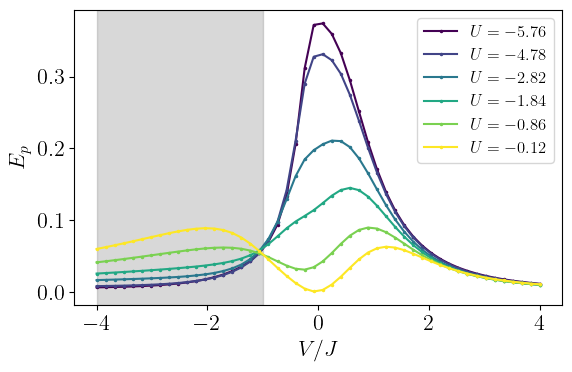

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")

ax.axvspan(-4.0, -1.0, color='grey', alpha=0.3, zorder=-1)

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax.plot(V_vals, E_p[i_U_fixed, :], 'o-', markersize=1.5, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$E_p$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/von_neumann_one_two_rdm_L={L}_fixed_U_positive.png", dpi=500, bbox_inches='tight')
plt.show()


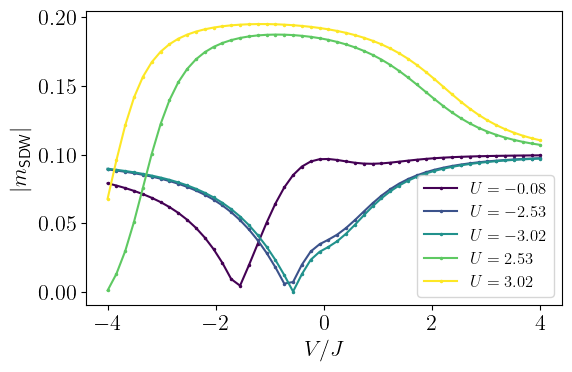

In [ ]:
V_targets = [0, -2.5, -3, 2.5, 3]

colors_neg = cm.viridis(np.linspace(0, 1, len(V_targets)))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plt.suptitle(f"$L = {L}$")

for color, V_target in zip(colors_neg, V_targets):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax.plot(V_vals, m_sdw[:, i_V_fixed], 'o-', markersize=1.5, color=color, label=fr"$U={V_vals[i_V_fixed]:.2f}$")

ax.set_xlabel(r"$V / J$")
ax.set_ylabel(r"$|m_{\text{SDW}}|$")
ax.legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/m_sdw_={L}_fixed_V_negative_.png", dpi=500, bbox_inches='tight')
plt.show()

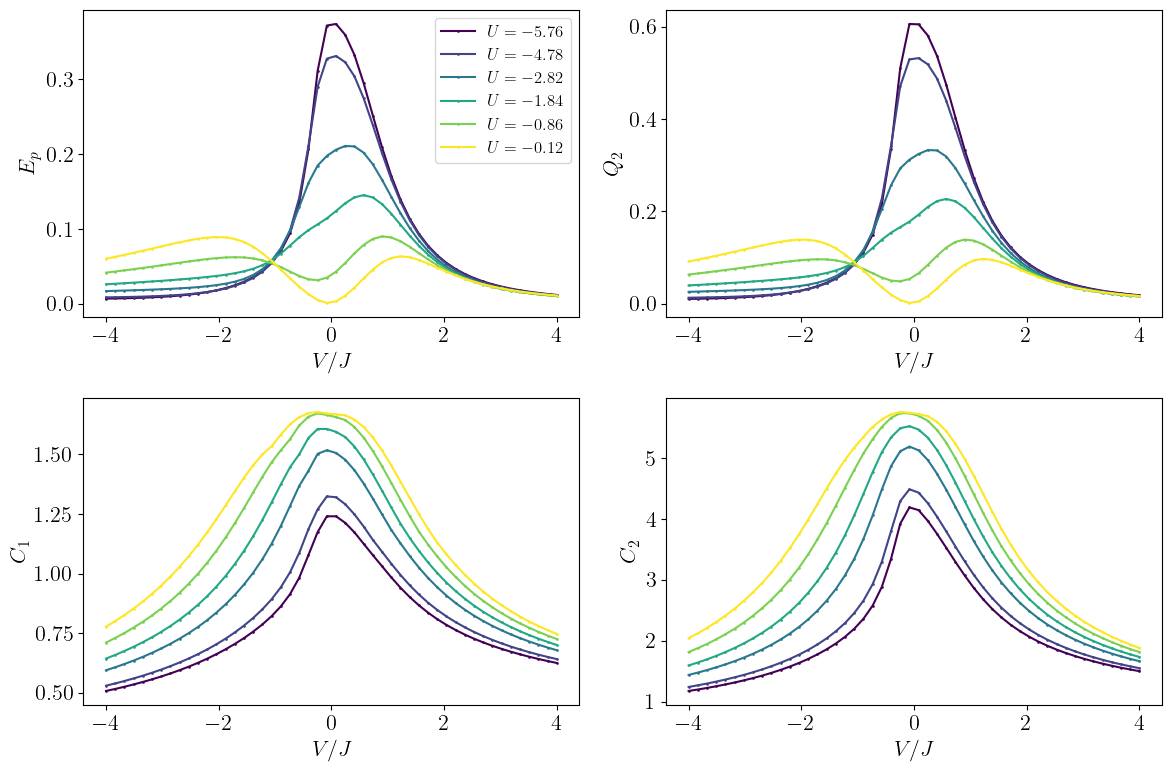

In [ ]:
colors_neg = cm.viridis(np.linspace(0, 1, len(U_targets_negatives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, U_target in zip(colors_neg, U_targets_negatives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,                 E_p[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,                 Q_2[i_U_fixed, :], 'o-', markersize=0.9, color=color)
    ax[1, 0].plot(V_vals, quantum_coherence_1[i_U_fixed, :], 'o-', markersize=0.9, color=color)
    ax[1, 1].plot(V_vals, quantum_coherence_2[i_U_fixed, :], 'o-', markersize=0.9, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_negative_.png",
            dpi=500, bbox_inches='tight')
plt.show()


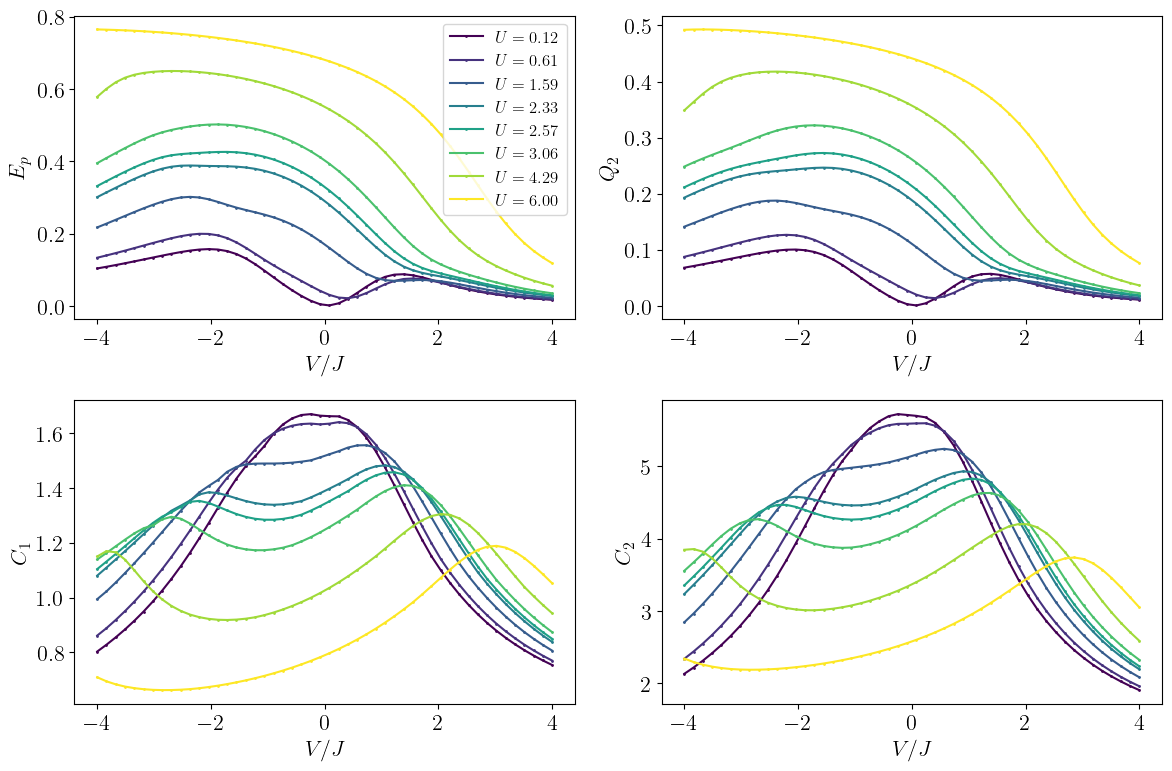

In [ ]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,                 Q_2[i_U_fixed, :], 'o-', markersize=1.0, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[0, 1].plot(V_vals,                 E_p[i_U_fixed, :], 'o-', markersize=1.0, color=color)
    ax[1, 0].plot(V_vals, quantum_coherence_1[i_U_fixed, :], 'o-', markersize=1.0, color=color)
    ax[1, 1].plot(V_vals, quantum_coherence_2[i_U_fixed, :], 'o-', markersize=1.0, color=color)

ax[0, 0].set_xlabel(r"$V / J$")
ax[0, 1].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")
ax[1, 1].set_xlabel(r"$V / J$")

ax[0, 0].set_ylabel(r"$E_p$")
ax[0, 1].set_ylabel(r"$Q_2$")
ax[1, 0].set_ylabel(r"$C_1$")
ax[1, 1].set_ylabel(r"$C_2$")

ax[0, 0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

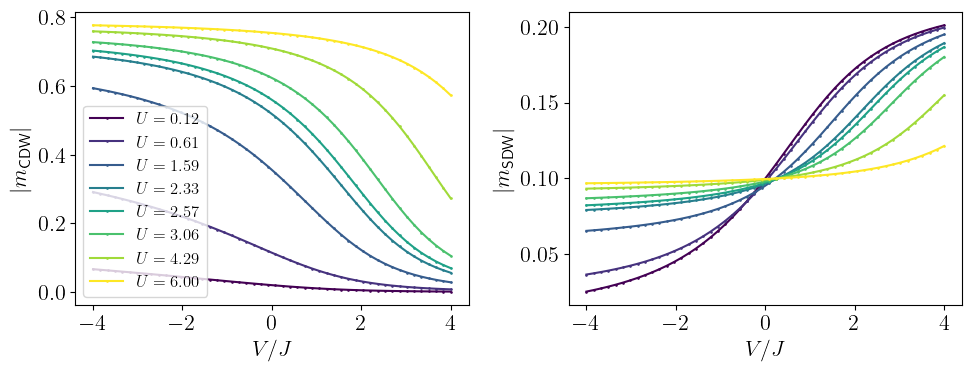

In [ ]:
colors_pos = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# plt.suptitle(f"$L = {L}$")

for color, U_target in zip(colors_pos, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")
    ax[1].plot(V_vals, m_sdw[i_U_fixed, :], 'o-', markersize=0.9, color=color, label=fr"$U={U_vals[i_U_fixed]:.2f}$")

ax[0].set_xlabel(r"$V / J$")
ax[1].set_xlabel(r"$V / J$")

ax[0].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_ylabel(r"$|m_{\text{SDW}}|$")

ax[0].legend(fontsize=12)

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_={L}_fixed_U_positive_.png", dpi=500, bbox_inches='tight')
plt.show()

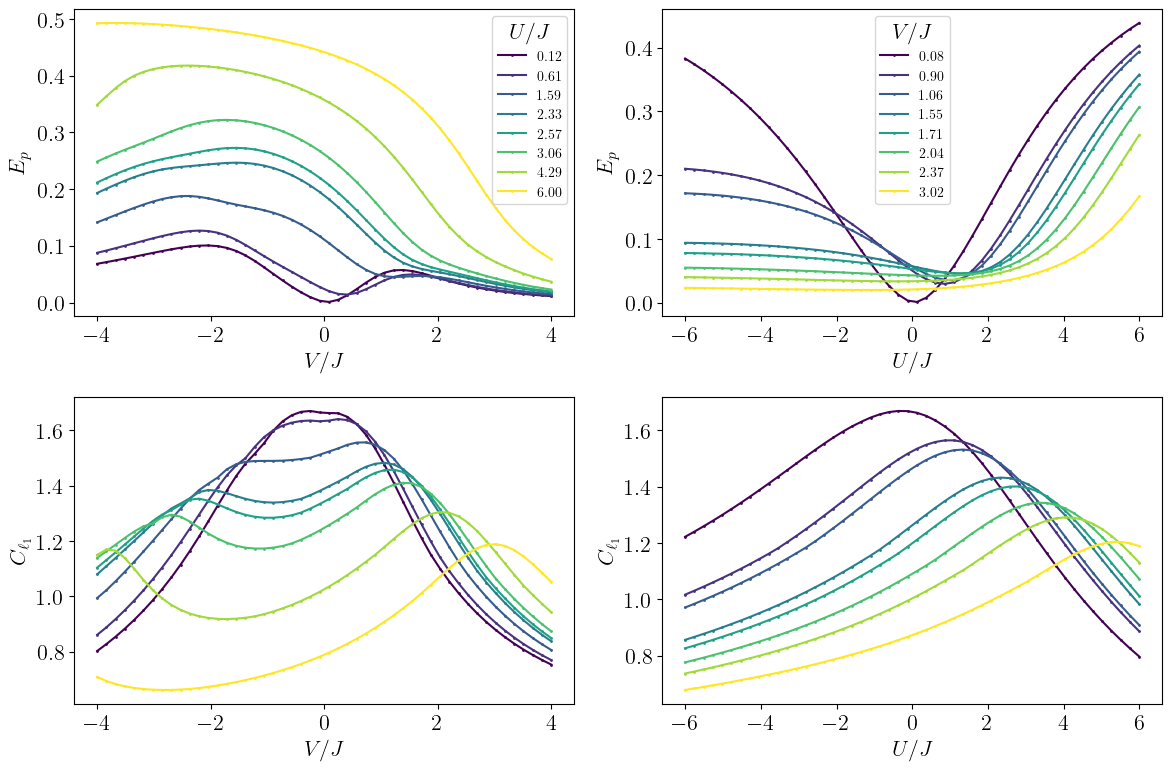

In [ ]:
colors_U = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for color, U_target in zip(colors_U, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[0, 0].plot(V_vals,                 E_p[i_U_fixed, :], 'o-', markersize=1.0, color=color, label=fr"${U_vals[i_U_fixed]:.2f}$")
    ax[1, 0].plot(V_vals, quantum_coherence_1[i_U_fixed, :], 'o-', markersize=1.0, color=color)

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0, 1].plot(U_vals,                 E_p[:, i_V_fixed], 'o-', markersize=1.0, color=color,  label=fr"${V_vals[i_V_fixed]:.2f}$")
    ax[1, 1].plot(U_vals, quantum_coherence_1[:, i_V_fixed], 'o-', markersize=1.0, color=color)

ax[0, 0].set_ylabel(r"$E_p$")
ax[1, 0].set_ylabel(r"$C_{\ell_1}$")
ax[0, 0].set_xlabel(r"$V / J$")
ax[1, 0].set_xlabel(r"$V / J$")

ax[0, 1].set_ylabel(r"$E_p$")
ax[1, 1].set_ylabel(r"$C_{\ell_1}$")
ax[0, 1].set_xlabel(r"$U / J$")
ax[1, 1].set_xlabel(r"$U / J$")

# ---- Legends ----
ax[0, 0].legend(fontsize=10, title=r"$U/J$", loc='best')
ax[0, 1].legend(fontsize=10, title=r"$V/J$", loc='best')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_combined_{L}.png", dpi=500, bbox_inches='tight')
plt.show()

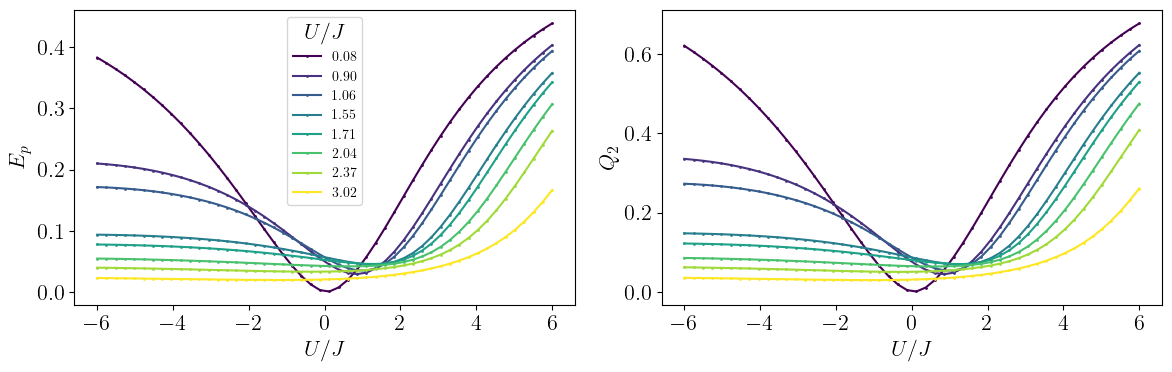

In [ ]:
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals,                 E_p[:, i_V_fixed], 'o-', markersize=1.0, color=color, label=fr"${V_vals[i_V_fixed]:.2f}$")
    ax[1].plot(U_vals,                 Q_2[:, i_V_fixed], 'o-', markersize=1.0, color=color)

ax[0].set_ylabel(r"$E_p$")
ax[0].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$Q_2$")
ax[1].set_xlabel(r"$U / J$")

# ---- Legends ----
ax[0].legend(fontsize=10, title=r"$U/J$", loc='best')

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_measures_combined_{L}.png", dpi=500, bbox_inches='tight')
plt.show()

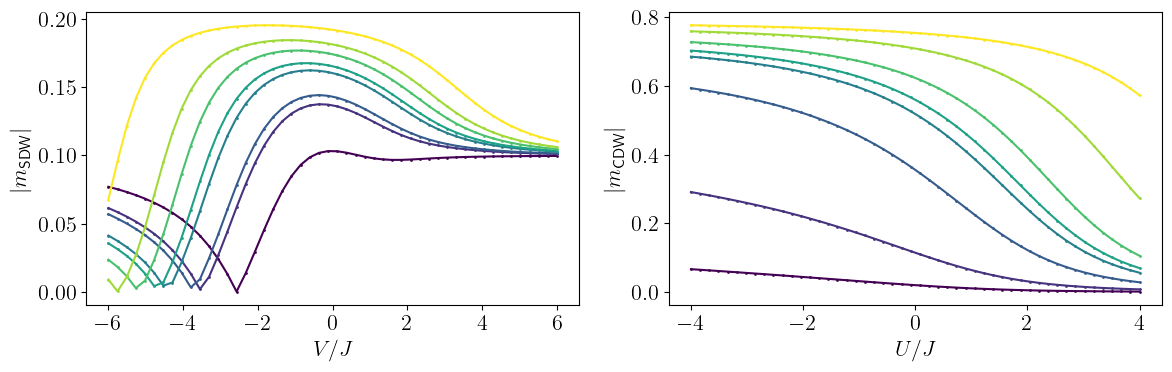

In [ ]:
colors_U = cm.viridis(np.linspace(0, 1, len(U_targets_positives)))
colors_V = cm.viridis(np.linspace(0, 1, len(V_targets_positives)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for color, U_target in zip(colors_U, U_targets_positives):
    i_U_fixed = np.argmin(np.abs(U_vals - U_target))
    ax[1].plot(V_vals, m_cdw[i_U_fixed, :], 'o-', markersize=1.0, color=color, label=fr"${U_vals[i_U_fixed]:.2f}$")

for color, V_target in zip(colors_V, V_targets_positives):
    i_V_fixed = np.argmin(np.abs(V_vals - V_target))
    ax[0].plot(U_vals,  m_sdw[:, i_V_fixed], 'o-', markersize=1.0, color=color,  label=fr"${V_vals[i_V_fixed]:.2f}$")

ax[0].set_ylabel(r"$|m_{\text{SDW}}|$")
ax[0].set_xlabel(r"$V / J$")

ax[1].set_ylabel(r"$|m_{\text{CDW}}|$")
ax[1].set_xlabel(r"$U / J$")

plt.tight_layout()
fig.savefig(f"{figures_path}/{model}_{exec}/order_parameters_combined_L={L}.png", dpi=500, bbox_inches='tight')
plt.show()